# Feature Selection — Hazard Ratios (Cox PH)

Fits a Cox Proportional Hazards model and compares the hazard ratios of all selected features to assess their relative impact on the risk of developing multiple myeloma.

`lifelines` is used here instead of `scikit-survival` because it exposes analytical standard errors and 95% confidence intervals directly from the fitted model — required for a proper forest plot.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lifelines import CoxPHFitter
from lifelines.utils import k_fold_cross_validation

## Load cleaned data

In [3]:
data_path = Path('cleaned_data/all_features.csv')
assert data_path.exists(), (
    "cleaned_data/myeloma_cleaned.csv not found — run clean_data.ipynb first."
)

df = pd.read_csv(data_path, index_col='ID')
print(f'Loaded {len(df)} rows')
df.head()

Loaded 2000 rows


,age,m_spike,sflc_ratio,creatinine,time_years,status,pgs_score,pgs_bin,bmpc,hgb,ancestry,was_bmpc_measured
ID,,,,,,,,,,,,
1,0.137747,2.422286,-0.287442,-1.718453,1.335000,1,0.012128,1,25.01001,14.598307,1,1
2,0.652230,2.640049,-0.247821,0.424321,0.066667,1,1.002874,1,NaN,15.478983,1,0
3,-0.033230,-0.725654,-0.319304,-0.646363,8.948333,0,0.732567,1,0.15043,12.717573,1,1
4,0.498547,0.015844,0.057345,0.067536,4.296667,1,0.829773,1,NaN,12.269072,1,0
5,-0.346698,1.190935,-0.568467,0.213709,3.765000,0,-0.778696,1,NaN,12.620185,1,0


## Fit Cox PH model

In [4]:
feature_cols = ['ancestry', 'age', 'm_spike', 'sflc_ratio', 'creatinine', 'pgs_score', 'was_bmpc_measured', 'hgb']
cols = feature_cols + ['time_years', 'status']

best_penalizer_l1_ration_pair = None
for penalizer in [0.001, 0.01, 0.1]:
    for l1_ratio in np.arange(0.0, 1.1, 0.1):
        cox = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
        c_index = np.mean(
            k_fold_cross_validation(
            cox,
            df[cols],
            duration_col='time_years',
            event_col='status',
            k=10,
            scoring_method="concordance_index"
            )
        )
        if best_penalizer_l1_ration_pair is None or c_index > best_penalizer_l1_ration_pair[2]:
            best_penalizer_l1_ration_pair = (penalizer, l1_ratio, c_index)

print(f'Best penalizer: {best_penalizer_l1_ration_pair[0]}, Best L1 ratio: {best_penalizer_l1_ration_pair[1]}, Best Concordance index: {best_penalizer_l1_ration_pair[2]:.4f}')
cox = CoxPHFitter(penalizer=best_penalizer_l1_ration_pair[0], l1_ratio=best_penalizer_l1_ration_pair[1])
cox.fit(df[cols], duration_col='time_years', event_col='status')

print(f'Concordance index: {cox.concordance_index_:.4f}')
cox.print_summary()

Best penalizer: 0.1, Best L1 ratio: 0.1, Best Concordance index: 0.7189
Concordance index: 0.7202


<lifelines.CoxPHFitter: fitted with 2000 total observations, 1481 right-censored observations>
             duration col = 'time_years'
                event col = 'status'
                penalizer = 0.1
                 l1 ratio = 0.1
      baseline estimation = breslow
   number of observations = 2000
number of events observed = 519
   partial log-likelihood = -3609.41
         time fit was run = 2026-03-27 15:54:56 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
ancestry           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
age                0.08      1.09      0.04            0.01            0.16                1.01                1.17
m_spike            0.44      1.56      0.04            0.38            0.51                1.46                1.67
sflc_ratio         0.12      1.13      0.02            0.08            0.17                1.08                1.18
creatinine         0.06      1.06      0.04           -0.01            0.13                0.99                1.14
pgs_score          0.23      1.25      0.04            0.15            0.30                1.16                1.35
was_bmpc_measured  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hgb               -0.11      0.89      0.03           -0.17           -0.06                0.85                0.94

                   cmp to     z      p  -log2(p)
covariate                                       
ancestry             0.00  0.00   1.00      0.00
age                  0.00  2.14   0.03      4.96
m_spike              0.00 12.61 <0.005    118.63
sflc_ratio           0.00  5.30 <0.005     23.05
creatinine           0.00  1.64   0.10      3.31
pgs_score            0.00  5.98 <0.005     28.73
was_bmpc_measured    0.00  0.00   1.00      0.00
hgb                  0.00 -4.23 <0.005     15.41
---
Concordance = 0.72
Partial AIC = 7234.81
log-likelihood ratio test = 208.03 on 8 df
-log2(p) of ll-ratio test = 132.50

## Extract hazard ratios and 95% CIs

Each coefficient is the log-hazard ratio for a **1 standard deviation increase** in that feature (features were standardized in `clean_data.ipynb`), so HRs are directly comparable across features.

- **HR > 1** — higher values associated with increased risk  
- **HR < 1** — higher values associated with decreased risk

In [6]:
s = cox.summary

summary = pd.DataFrame({
    'HR':       s['exp(coef)'],
    'CI_lower': s['exp(coef) lower 95%'],
    'CI_upper': s['exp(coef) upper 95%'],
    'p':        s['p'],
    '-log2(p)':    s['-log2(p)']
}).sort_values('HR', ascending=True)   # ascending=True so highest HR is at the top when plotted

summary

,HR,CI_lower,CI_upper,p,-log2(p)
covariate,,,,,
hgb,0.891821,0.845791,0.940356,2.291206e-05,15.413533
ancestry,1.000001,0.997164,1.002846,9.994141e-01,0.000845
was_bmpc_measured,1.000002,0.997589,1.002421,9.987346e-01,0.001827
creatinine,1.063373,0.988135,1.144341,1.007648e-01,3.310937
age,1.085069,1.007017,1.169171,3.206953e-02,4.962653
sflc_ratio,1.129699,1.079898,1.181797,1.147900e-07,23.054500
pgs_score,1.252868,1.163627,1.348953,2.238344e-09,28.734921
m_spike,1.559688,1.455547,1.671279,1.938565e-36,118.634422


## Forest plot

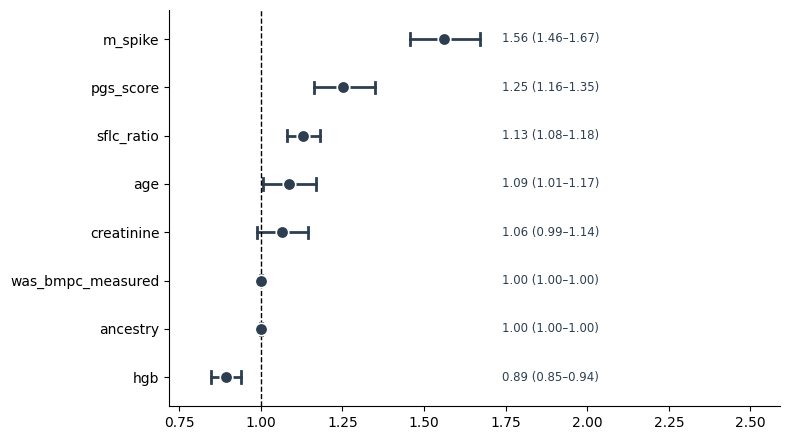

In [7]:

COLOR = '#2c3e50'

fig, ax = plt.subplots(figsize=(8, 4.5))

y_pos    = np.arange(len(summary))
features = summary.index.tolist()
hrs      = summary['HR'].values
ci_lower = summary['CI_lower'].values
ci_upper = summary['CI_upper'].values

for i, (hr, lo, hi) in enumerate(zip(hrs, ci_lower, ci_upper)):
    ax.plot([lo, hi], [i, i], color=COLOR, linewidth=2, zorder=2)
    ax.plot([lo, lo], [i - 0.12, i + 0.12], color=COLOR, linewidth=2, zorder=2)
    ax.plot([hi, hi], [i - 0.12, i + 0.12], color=COLOR, linewidth=2, zorder=2)
    ax.plot(hr, i, 'o', color=COLOR, markersize=9, zorder=3,
            markeredgecolor='white', markeredgewidth=1.2)
    ax.text(
        ci_upper.max() * 1.04, i,
        f'{hr:.2f} ({lo:.2f}–{hi:.2f})',
        va='center', ha='left', fontsize=8.5, color=COLOR
    )

ax.axvline(x=1, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=10)
ax.set_xlim(ci_lower.min() * 0.85, ci_upper.max() * 1.55)
ax.set_ylim(-0.6, len(summary) - 0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("img/feature_comparison.svg")
plt.show()


## Rank features by absolute effect size

In [10]:
ranking = summary.copy()
ranking['abs_log_HR'] = np.log(ranking['HR']).abs()
ranking = ranking.sort_values('abs_log_HR', ascending=False)
ranking[['HR', 'CI_lower', 'CI_upper', 'p', 'abs_log_HR']]

,HR,CI_lower,CI_upper,p,abs_log_HR
covariate,,,,,
m_spike,1.812927,1.685440,1.950056,1.453722e-57,5.949424e-01
pgs_score,1.402900,1.290766,1.524775,1.651969e-15,3.385414e-01
hgb,0.830122,0.780994,0.882340,2.208184e-09,1.861828e-01
age,1.165842,1.070429,1.269760,4.278939e-04,1.534438e-01
sflc_ratio,1.159631,1.113002,1.208213,1.518574e-12,1.481016e-01
creatinine,1.114385,1.027121,1.209063,9.236570e-03,1.083029e-01
was_bmpc_measured,1.000008,0.991678,1.008407,9.985754e-01,7.620035e-06
ancestry,1.000000,0.993127,1.006921,9.999357e-01,2.837535e-07


## Is PGS bin sufficient to replace PGS score?

In [12]:
base_cols = ['age', 'm_spike', 'sflc_ratio', 'creatinine', 'time_years', 'status']

def test_model(cols):
    cph = CoxPHFitter()
    return k_fold_cross_validation(cph, df[cols], duration_col='time_years', event_col='status', k=5, scoring_method="concordance_index")

scores_pgs = test_model(base_cols + ['pgs_score'])
scores_bin = test_model(base_cols + ['pgs_bin'])

print(f'C-Index with PGS Scores: {np.mean(scores_pgs):.3f} ± {np.std(scores_pgs):.3f}')
print(f'C-Index with PGS Bins:   {np.mean(scores_bin):.3f} ± {np.std(scores_bin):.3f}')

C-Index with PGS Scores: 0.706 ± 0.016
C-Index with PGS Bins:   0.704 ± 0.033
